
# EE-411 Lottery Ticket Hypothesis -  Priting for all CNN Model ( Conv2, Conv4. Conv6) : Random Pruning and Iterative Pruning

**Author:** Xavier  
**Model:** Conv6
**Dataset:** CIFAR-10  
**Date:** 17/01/2026

---


EE-411 Lottery Ticket Hypothesis - Priting
Author: Xavier
Model: Conv6 Dataset: CIFAR-10
Date: 17/01/2026

Instructions : Load your results and print it on a common curve to follow the Figure 1 template


In [3]:
# Let's import the useful libraries

import random
import numpy as np
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.nn.functional as F
import time
import copy
import torch
import json, os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Fix all random seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# For full determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Import the best device available
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: mps


In [10]:
from pathlib import Path

# from notebook/ -> project root -> results/
RESULTS_DIR = Path("..") / "results"

In [11]:
from pathlib import Path
import json


RESULTS_PATH_conv6 = RESULTS_DIR / "conv6_results.json"
RESULTS_PATH_conv4 = RESULTS_DIR / "conv4_results_ticket.json"
RESULTS_PATH_conv2 = RESULTS_DIR / "conv2_results.json"

RESULTS_PATH_RANDOM_conv6 = RESULTS_DIR / "conv6_results_random.json"
RESULTS_PATH_RANDOM_conv4 = RESULTS_DIR / "conv4_random.json"
RESULTS_PATH_RANDOM_conv2 = RESULTS_DIR / "conv2_results_random.json"

def load_results(path: Path):
    path = Path(path)
    if path.exists():
        with open(path, "r") as f:
            return json.load(f)
    return {}

In [13]:
# Load the results 

conv_6_ticket = load_results(RESULTS_PATH_conv6)["ticket"]
conv_6_rand = load_results(RESULTS_PATH_RANDOM_conv6)["random"]


conv_4_rand = load_results(RESULTS_PATH_RANDOM_conv4)["random"]
conv_4_ticket =load_results(RESULTS_PATH_conv4)["ticket"]


conv_2_rand = load_results(RESULTS_PATH_conv2)["random"]
conv_2_ticket = load_results(RESULTS_PATH_conv2)["ticket"]

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_figure_two(
    random_res_conv6, random_res_conv4, random_res_conv2,
    ticket_res_conv6, ticket_res_conv4, ticket_res_conv2,
):
    def summarize(res):
        """
        Accepts either:
          A) old format: list of (kr, iters_tensor, accs_tensor)
          B) your JSON format: dict { "kr=..._trial=...": {"keep_ratio":..., "best_iter":..., "test_acc":...}, ... }
        Returns:
          x(%), mean_iters_k, std_iters_k, mean_acc, std_acc
        """
        # --- Case B: dict from JSON ---
        if isinstance(res, dict):
            grouped = {}  # kr -> {"iters": [...], "accs": [...]}
            for entry in res.values():
                kr = float(entry["keep_ratio"])
                grouped.setdefault(kr, {"iters": [], "accs": []})
                grouped[kr]["iters"].append(float(entry["best_iter"]))
                grouped[kr]["accs"].append(float(entry["test_acc"]))

            krs = sorted(grouped.keys(), reverse=True)
            x = np.array([kr * 100 for kr in krs])

            mean_iters_k = np.array([np.mean(grouped[kr]["iters"]) for kr in krs]) / 1000.0
            std_iters_k  = np.array([np.std(grouped[kr]["iters"])  for kr in krs]) / 1000.0

            mean_acc = np.array([np.mean(grouped[kr]["accs"]) for kr in krs])
            std_acc  = np.array([np.std(grouped[kr]["accs"])  for kr in krs])

            return x, mean_iters_k, std_iters_k, mean_acc, std_acc

        # --- Case A: list-of-tuples (original) ---
        x = np.array([kr * 100 for kr, _, _ in res])
        mean_iters_k = np.array([r[1].mean().item() for r in res]) / 1000.0
        std_iters_k  = np.array([r[1].std(unbiased=False).item() for r in res]) / 1000.0
        mean_acc     = np.array([r[2].mean().item() for r in res])
        std_acc      = np.array([r[2].std(unbiased=False).item() for r in res])
        return x, mean_iters_k, std_iters_k, mean_acc, std_acc

    series = [
        ("Conv-6", "#ff7f0e", random_res_conv6, ticket_res_conv6),
        ("Conv-4", "#2ca02c", random_res_conv4, ticket_res_conv4),
        ("Conv-2", "#1f77b4", random_res_conv2, ticket_res_conv2),
    ]

    xticks = np.array([100.0, 41.2, 17.0, 7.1, 3.0, 1.3])
    xticklabels = ["100", "41.2", "17.0", "7.1", "3.0", "1.3"]

    # ---- Figure 1 (left): iteration of minimum val loss (K) ----
    plt.figure(figsize=(10, 5))
    for name, color, rand_res, tick_res in series:
        x_r, mi_r, si_r, _, _ = summarize(rand_res)
        x_t, mi_t, si_t, _, _ = summarize(tick_res)

        plt.errorbar(x_r, mi_r, yerr=si_r, linestyle=":", marker="o", capsize=3,
                     color=color, label=f"{name} random")
        plt.errorbar(x_t, mi_t, yerr=si_t, linestyle="-", marker="o", capsize=3,
                     color=color, label=f"{name} ticket")

    plt.xlabel("Percent of Weights Remaining")
    plt.ylabel("Iteration of Minimum Validation Loss (K)")

    ax = plt.gca()
    ax.set_xscale('log')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.invert_xaxis()
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Figure 1 (right): test accuracy at that iteration ----
    plt.figure(figsize=(10, 5))
    for name, color, rand_res, tick_res in series:
        x_r, _, _, ma_r, sa_r = summarize(rand_res)
        x_t, _, _, ma_t, sa_t = summarize(tick_res)

        plt.errorbar(x_r, ma_r, yerr=sa_r, linestyle=":", marker="o", capsize=3,
                     color=color, label=f"{name} random")
        plt.errorbar(x_t, ma_t, yerr=sa_t, linestyle="-", marker="o", capsize=3,
                     color=color, label=f"{name} ticket")

    plt.xlabel("Percent of Weights Remaining")
    plt.ylabel("Test Accuracy at Best-Validation Iteration")

    ax = plt.gca()
    ax.set_xscale('log')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.invert_xaxis()
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())

    plt.legend()
    plt.tight_layout()
    plt.show()

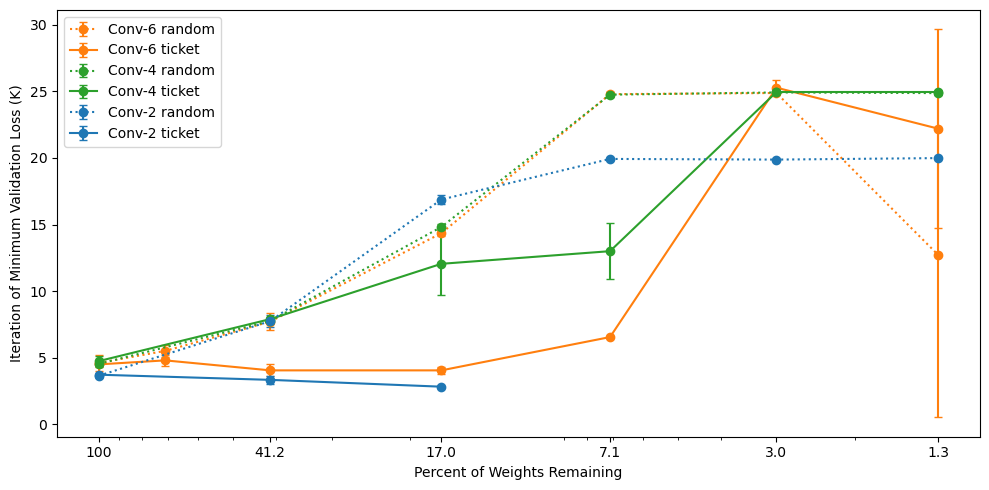

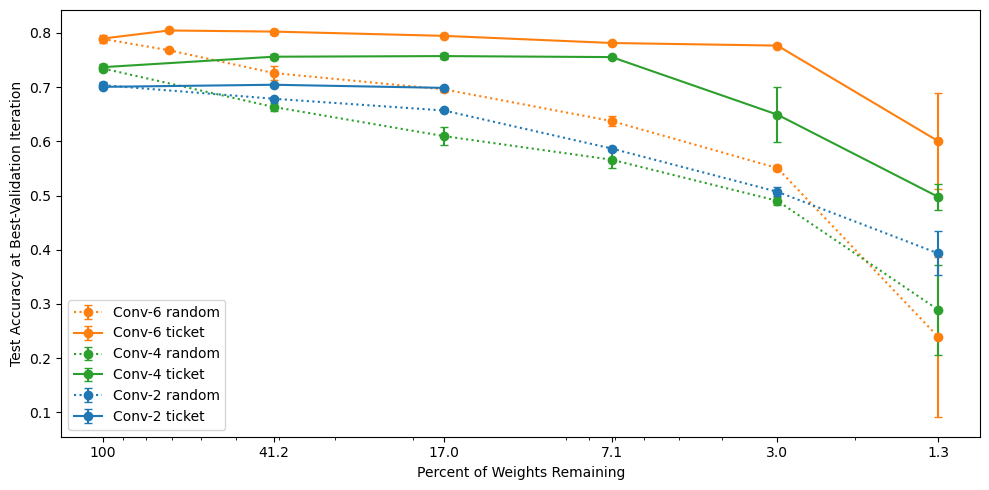

In [15]:
plot_figure_two(conv_6_rand,conv_4_rand,conv_2_rand,conv_6_ticket,conv_4_ticket,conv_2_ticket)